# Marketing Linear Multiple Regression Problem

## Dataset
 https://www.kaggle.com/datasets/fayejavad/marketing-linear-multiple-regression

## About dataset
 The advertising experiment between Social Media Budget and Sales (in thousands $).
 | Name      | Type    | Description                                |
 |-----------|---------|--------------------------------------------|
 | youtube   | Numeric | Advertising budget spent on YouTube ads.  |
 | facebook  | Numeric | Advertising budget spent on Facebook ads. |
 | newspaper | Numeric | Advertising budget spent on Newspaper ads.|
 | sales     | Numeric | Total sales generated (Target variable).  |

## Business Problem
 The goal of this analysis is to determine the most effective allocation of the marketing budget. We aim to identify which advertising channels (YouTube, Facebook, or Newspaper) yield the highest Return on Investment (ROI) and how to maximize sales while minimizing wasteful spending.

# Libraries import

In [199]:
from patsy import dmatrices
import pandas as pd
import kagglehub
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import math
import seaborn as sns
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf

# Load dataset

In [200]:
kagglehub.dataset_download("fayejavad/marketing-linear-multiple-regression", output_dir="data", force_download=True)

100%|██████████| 1.86k/1.86k [00:00<00:00, 1.93MB/s]

Extracting files...


'data'

In [201]:
df = pd.read_csv('./data/Marketing_Data.csv')
df.head()

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


# Dataset analysis (EDA)

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   youtube    171 non-null    float64
 1   facebook   171 non-null    float64
 2   newspaper  171 non-null    float64
 3   sales      171 non-null    float64
dtypes: float64(4)
memory usage: 5.5 KB


In [203]:
df.describe()

,youtube,facebook,newspaper,sales
count,171.000000,171.000000,171.000000,171.000000
mean,178.021053,27.671579,35.240000,16.922807
std,102.449597,17.913532,24.902918,6.314608
min,0.840000,0.000000,0.360000,1.920000
25%,91.080000,11.700000,13.740000,12.540000
50%,179.760000,26.760000,31.080000,15.480000
75%,262.980000,43.680000,50.880000,20.820000
max,355.680000,59.520000,121.080000,32.400000


The dataset consists of four numerical features. The descriptive statistics indicate that the company allocates its largest budget to YouTube marketing.

Correlation check

In [204]:
correlation_matrix = df.corr()
correlation_matrix

,youtube,facebook,newspaper,sales
youtube,1.000000,0.086538,0.110759,0.782030
facebook,0.086538,1.000000,0.293425,0.602918
newspaper,0.110759,0.293425,1.000000,0.254987
sales,0.782030,0.602918,0.254987,1.000000


 * There is a strong correlation between YouTube ads and sales.
 * There is also a moderate correlation between facebook ads and sales.
 * Correlation between newspaper and sales is low.

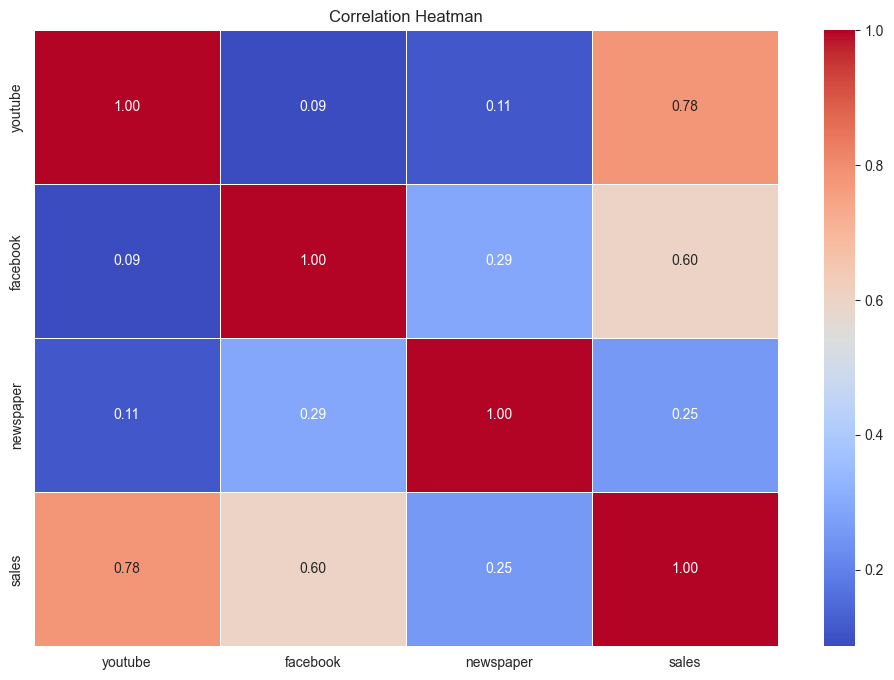

In [205]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatman")
plt.show()

There is no strong correlation between independent variables.

Check for empty values

In [206]:
df.isna().sum()

youtube      0
facebook     0
newspaper    0
sales        0
dtype: int64

There are no empty values.

Check for duplicated rows

In [207]:
df.duplicated().sum()

np.int64(0)

There are no duplicated rows.

## Youtube

In [208]:
#youtube
print("Median: ",df['youtube'].median())
print("Mean: ",df['youtube'].mean())

Median:  179.76
Mean:  178.02105263157893


The median and the mean are similar to each other.

In [209]:
print("Skewness: ", stats.skew(df['youtube']))
print("Kurtosis: ", stats.kurtosis(df['youtube']))

Skewness:  -0.06269024451010069
Kurtosis:  -1.1882070628525745


 * Distribution is symetric.
 * The distribution is platykurtic.

Text(0, 0.5, 'amount')

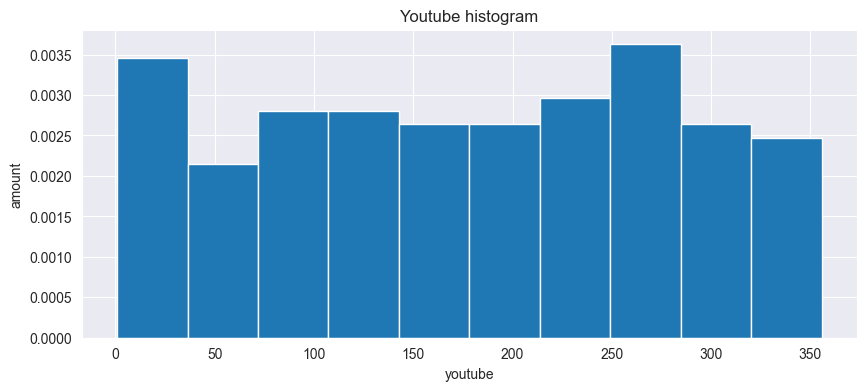

In [210]:
fig = plt.figure(figsize=(10,4))
df['youtube'].hist(density=True)

plt.title('Youtube histogram')
plt.xlabel('youtube')
plt.ylabel('amount')

 * The feature's distribution does not resemble a normal distribution.
 * The values are fairly evenly distributed.
 * We observe two peaks corresponding to low-cost campaigns (0–40) and relatively expensive ones (250–280).

Check for outliers

Text(0, 0.5, 'value')

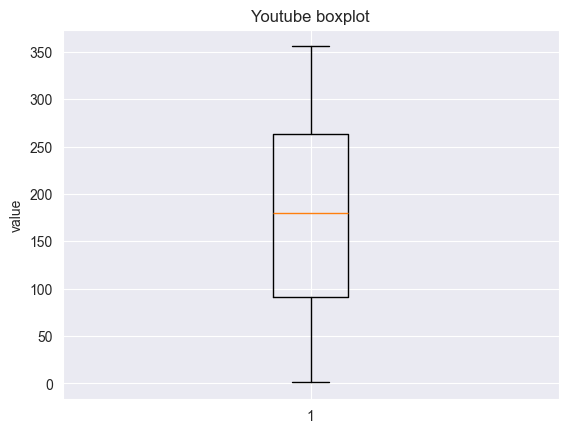

In [211]:
plt.boxplot(x=df['youtube'])
plt.title("Youtube boxplot")
plt.ylabel('value')

There are no outliers.

## Facebook

In [212]:
print("Median: ",df['facebook'].median())
print("Mean: ",df['facebook'].mean())

Median:  26.76
Mean:  27.67157894736842


Median and mean are similar to each other.

In [213]:
print("Skewness: ", stats.skew(df['facebook']))
print("Kurtosis: ", stats.kurtosis(df['facebook']))

Skewness:  0.11115108761736622
Kurtosis:  -1.2673549423484574


 * The distribution is right-skewed.
 * The distribution is platykurtic.

Text(0, 0.5, 'amount')

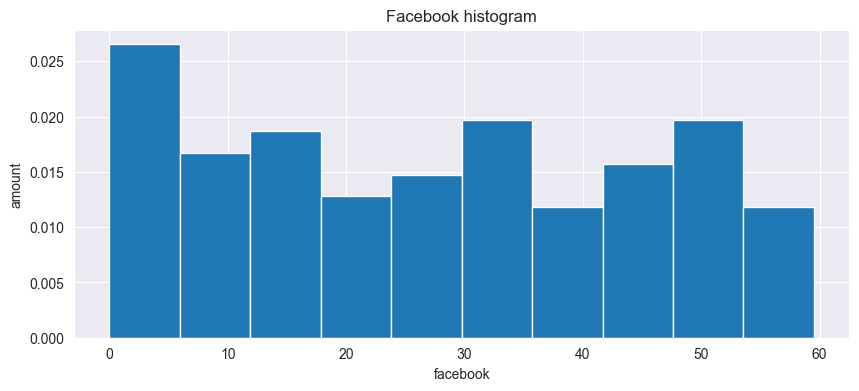

In [214]:
fig = plt.figure(figsize=(10,4))
df['facebook'].hist(density=True)

plt.title('Facebook histogram')
plt.xlabel('facebook')
plt.ylabel('amount')

The Facebook spending histogram is slightly right-skewed. The data are spread across the entire range, with a relatively flat profile. The most common campaigns are the cheaper ones (0–5)

Check for outliers

Text(0, 0.5, 'value')

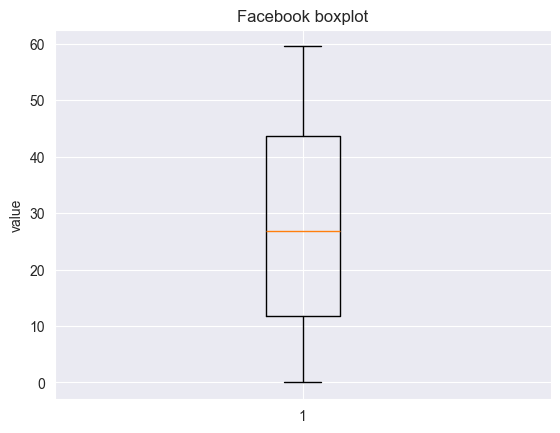

In [215]:
plt.boxplot(x=df['facebook'])
plt.title("Facebook boxplot")
plt.ylabel('value')

There are no outliers.

## Newspaper

In [216]:
print("Median: ",df['newspaper'].median())
print("Mean: ",df['newspaper'].mean())

Median:  31.08
Mean:  35.24


The median is slightly lower than the mean, which indicates that the distribution is propably right-skewed.

In [217]:
print("Skewness: ", stats.skew(df['newspaper']))
print("Kurtosis: ", stats.kurtosis(df['newspaper']))

Skewness:  0.8158248416151072
Kurtosis:  0.28826059836371787


 * The distribution is right-skewed.
 * Distribution is mesokurtic.

Text(0, 0.5, 'Amount')

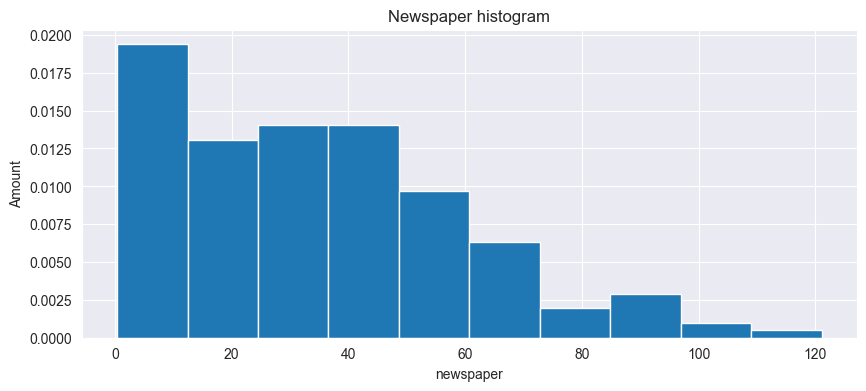

In [218]:
fig = plt.figure(figsize=(10,4))
df['newspaper'].hist(density=True)

plt.title('Newspaper histogram')
plt.xlabel('newspaper')
plt.ylabel('Amount')

The newspaper advertising spend follows a right-skewed distribution. Most of the data points are concentrated at the lower end of the scale (0-40), with a long tail extending towards higher values. This indicates that while the company typically maintains a low or moderate budget for newspapers, there are occasional high-spend outliers exceeding 100 units.

Check for outliers

Text(0, 0.5, 'value')

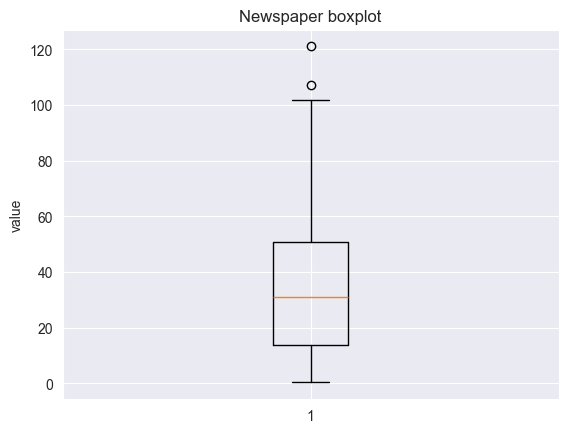

In [219]:
plt.boxplot(x=df['newspaper'])
plt.title("Newspaper boxplot")
plt.ylabel('value')

There are a few outliers – extremely expensive campaigns.

## Sales

In [220]:
print("Median: ",df['sales'].median())
print("Mean: ",df['sales'].mean())

Median:  15.48
Mean:  16.922807017543857


Median and mean are similar to each other.

In [221]:
print("Skewness: ", stats.skew(df['sales']))
print("Kurtosis: ", stats.kurtosis(df['sales']))

Skewness:  0.4039349318862532
Kurtosis:  -0.4247432629970054


 * The distribution is right-skewed.
 * The distribution is almost mesokurtic.

Text(0, 0.5, 'Amount')

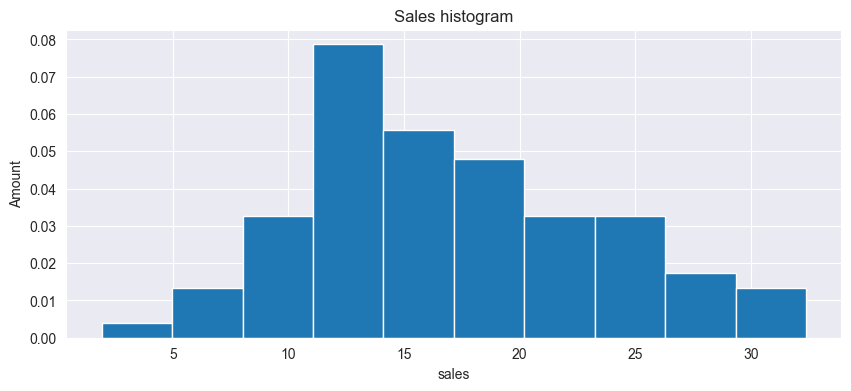

In [222]:
fig = plt.figure(figsize=(10,4))
df['sales'].hist(density=True)

plt.title('Sales histogram')
plt.xlabel('sales')
plt.ylabel('Amount')

The sales histogram is similar to a normal distribution, with a slight right skew. Most sales figures are concentrated between 11 and 14 units. The tail extending toward 30 units indicates that while high-performing periods occur, they are less frequent than average-performance periods.

Check for outliers

Text(0, 0.5, 'value')

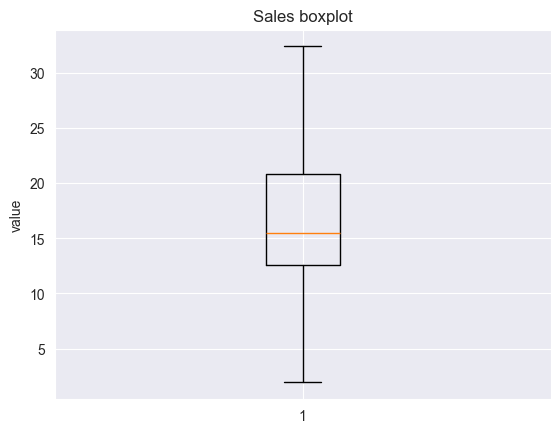

In [223]:
plt.boxplot(x=df['sales'])
plt.title("Sales boxplot")
plt.ylabel('value')

There are no outliers.

***
# Building a Linear Regression Model

In [224]:
y = df['sales']
X_multi = sm.add_constant(df[["youtube", "facebook", "newspaper"]])

In [225]:
model_multi = sm.OLS(y, X_multi)
results_multi = model_multi.fit()

In [226]:
summary_multi = results_multi.summary()
summary_multi

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     503.7
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           2.09e-83
Time:                        01:33:14   Log-Likelihood:                -359.99
No. Observations:                 171   AIC:                             728.0
Df Residuals:                     167   BIC:                             740.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5059      0.400      8.772      0.000       2.717       4.295
youtube        0.0452      0.002     29.830      0.000       0.042       0.048
facebook       0.1884      0.009     20.895      0.000       0.171       0.206
newspaper      0.0043      0.007      0.658      0.511      -0.009       0.017
==============================================================================
Omnibus:                       57.934   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              162.792
Skew:                          -1.388   Prob(JB):                     4.47e-36
Kurtosis:                       6.891   Cond. No.                         544.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

***
# Regression Assumptions Verification

## 1. Bivariate Linearity Analysis

**General Definition**

This condition assumes that when all other predictors are held constant ("frozen"), there is a direct, straight-line relationship between a single independent variable and the dependent variable. It ensures that the specific contribution of each factor to the outcome is additive and remains constant across its entire range.

**Application to the Example**

In our model, this means that if we keep the Facebook and Newspaper budgets fixed, any change in the YouTube budget will result in a steady, linear change in Sales. To verify this, we use **Partial Regression Plots**, which isolate the "pure" effect of each individual variable by removing the influence of all other predictors, allowing us to visually confirm if the relationship is indeed a straight line.

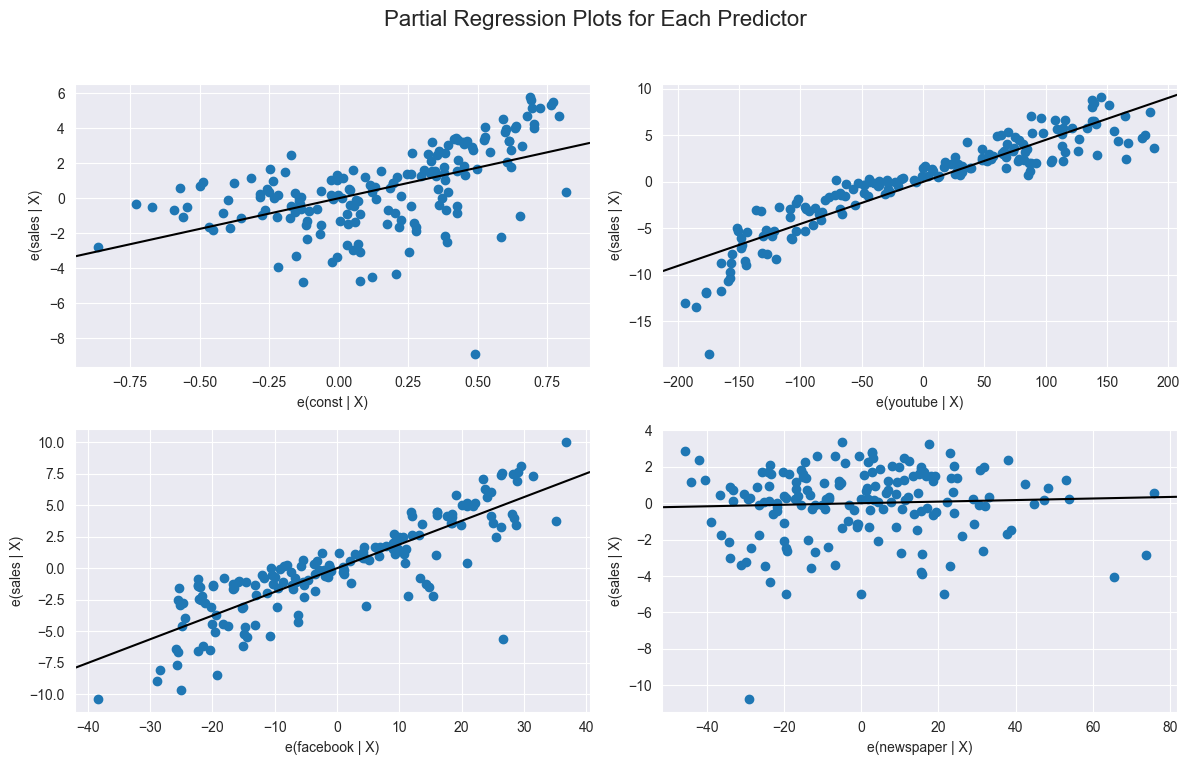

In [227]:
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_partregress_grid(results_multi, fig=fig)

fig.suptitle("Partial Regression Plots for Each Predictor", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

**Model Diagnostics: Partial Regression Analysis**

These plots isolate the "pure" effect of each advertising channel on Sales by holding the other variables constant (ceteris paribus).

* **Intercept** `e(const | X)`:

Confirms the baseline sales level that occurs independently of the advertising budget.

* **YouTube** `e(youtube | X)`:

Shows a strong, positive linear relationship. The tight clustering indicates that YouTube spend is the most reliable predictor of sales.

* **Facebook** `e(facebook | X)`:

Shows a clear linear impact. While slightly more dispersed than YouTube, it remains a significant driver of revenue.

* **Newspaper** `e(newspaper | X)`:

Shows a flat relationship. The random scatter indicates that newspaper ads provide no unique predictive value when other channels are present.

**Summary**

The plots clearly demonstrate that YouTube and Facebook are the primary drivers of sales, maintaining a strong linear connection. In contrast, Newspaper advertising shows no significant impact, suggesting that budget allocated to this channel does not effectively contribute to revenue growth in this model.

**Mathematical Background: The Frisch-Waugh-Lovell Theorem**

To visualize the isolated effect of a single variable, the model utilizes **Partial Regression Plots (also known as Added Variable Plots)**. Instead of a simple bivariate regression, the algorithm follows the "Residual-Residual" method based on the **Frisch-Waugh-Lovell Theorem**.

Using **YouTube** as an example, the process works as follows:

* Isolating the Dependent Variable ($Y$): We regress Sales against all other independent variables (**Facebook** and **Newspaper**) and extract the residuals ($e_{Sales | X}$). These residuals represent the portion of Sales that cannot be explained by Facebook or Newspaper advertising.

* Isolating the Independent Variable ($X_1$): We regress YouTube against the other predictors (Facebook and Newspaper) and extract those residuals ($e_{YouTube | X}$). This represents the unique variation in the YouTube budget that is completely independent of the other media spends.

* The Final Visualization: The plot displays these two sets of residuals against each other. By "clearing out" the influence of other variables, the resulting slope is identical to the partial regression coefficient ($\beta$) for YouTube in the full multiple regression model.

## 2. Linearity in Parameters

This assumption is satisfied by the functional form of our model:

$Sales = \beta_0 + \beta_1 \cdot YouTube + \beta_2 \cdot Facebook + \beta_3 \cdot Newspaper + \epsilon$

While the relationship between the variables themselves is visualized via partial regression plots, the model is mathematically "linear in parameters" because all coefficients ($\beta$) enter the equation linearly. This allows us to use Ordinary Least Squares (OLS) for estimation.

## 3. Homoscedasticity (Constant Variance of Residuals)

**Mathematical Definition**

The assumption of homoscedasticity states that the variance of the error term, conditional on the explanatory variables, is constant:$$Var(\epsilon_i | X_i) = \sigma^2$$This means that for every observation $i$, the expected "spread" of the error $\epsilon$ is the same constant value $\sigma^2$. If this variance changes depending on the values of $X$ (e.g., $Var(\epsilon_i | X_i) = \sigma_i^2$), we have heteroscedasticity.

**Application to the Example**

In our advertising model, this ensures that our predictions for Sales are equally reliable regardless of whether the advertising budget is small or large. If we had heteroscedasticity (e.g., a "fan" shape where errors grow with higher spend), our standard errors would be biased, making our $p$-values and confidence intervals untrustworthy.

**Verification Methods**

To verify this, we use both visual and statistical diagnostics:

* **Residuals vs. Fitted Plot:** We look for a random "cloud" of points. A "fan" or "funnel" shape indicates heteroscedasticity.

* **Breusch-Pagan Test:** A formal statistical test where a p-value < 0.05 suggests that the constant variance assumption is violated.

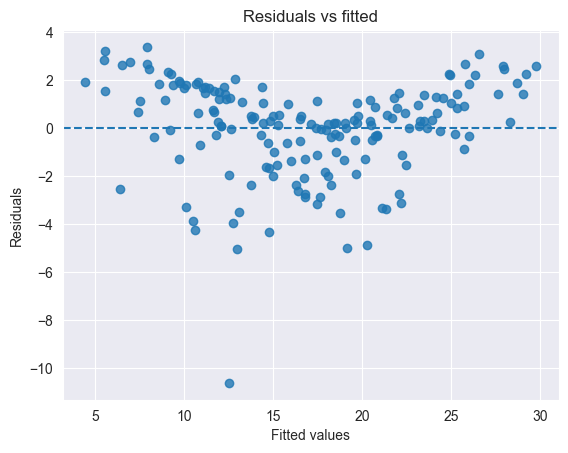

In [228]:
fitted_multi = results_multi.fittedvalues
resid_multi = results_multi.resid

plt.scatter(fitted_multi, resid_multi, alpha=0.8)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted")
plt.show()

**Summary**

The model suffers from specification bias. The systematic pattern in the residuals indicates that a simple linear equation fails to capture the full complexity of the data, and further transformations (like $log$ or interaction terms) might be necessary.

## 4. Normality of Residuals

**Mathematical Definition**

The assumption of normality states that the error terms ($\epsilon$) of the model should follow a normal distribution with a mean of zero and a constant variance:

$$\epsilon \sim N(0, \sigma^2)$$

**General Definition**

In plain terms, this assumption ensures that the "unexplained" part of our sales data (the noise) is random and balanced. We want our model to be wrong in a consistent, bell-shaped way—not consistently overestimating or underestimating sales in a skewed manner.

**Why It Matters**

While the model can still produce good estimates without normality, this assumption is critical for **statistical inference**. Specifically, it is required to:

* Calculate accurate **p-values** for our advertising channels (YouTube, Facebook, etc.).

* Construct reliable **confidence intervals**.

* Perform valid **t-tests** and **F-tests** to determine if a variable is statistically significant.

**Verification Methods**

To check if our residuals are normally distributed, we use:

1. **Q-Q Plot (Quantile-Quantile Plot):** This is the most effective visual tool. We plot the theoretical quantiles of a normal distribution against the actual quantiles of our residuals.

    * Ideal Result: The points fall exactly along a straight diagonal line.

    * Violation: If the points curve away from the line at the ends ("heavy tails"), the residuals are not normal.

2. **Histogram of Residuals:** We plot the frequency of the errors to see if they form a symmetric "bell curve".
3. **Statistical Tests (e.g., Jarque-Bera or Shapiro-Wilk)**: These tests provide a formal p-value.
    * Null Hypothesis ($H_0$): The residuals are normally distributed.
    * Decision: A p-value < 0.05 indicates that we reject the normality assumption.

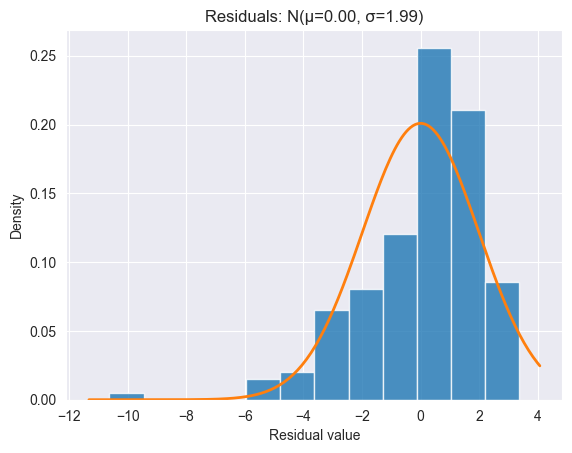

In [229]:
mu_multi, sigma_multi = stats.norm.fit(resid_multi)

plt.hist(resid_multi, bins=12, density=True, alpha=0.8)
xmin_multi, xmax_multi = plt.xlim()
x_line_multi = np.linspace(xmin_multi, xmax_multi, 200)
plt.plot(x_line_multi, stats.norm.pdf(x_line_multi, mu_multi, sigma_multi), linewidth=2)

plt.title(f"Residuals: N(μ={mu_multi:.2f}, σ={sigma_multi:.2f})")
plt.xlabel("Residual value")
plt.ylabel("Density")
plt.show()

The distribution is slightly left-skewed and leptokurtic (we can see a high peak around zero and heavy tails on the left side).

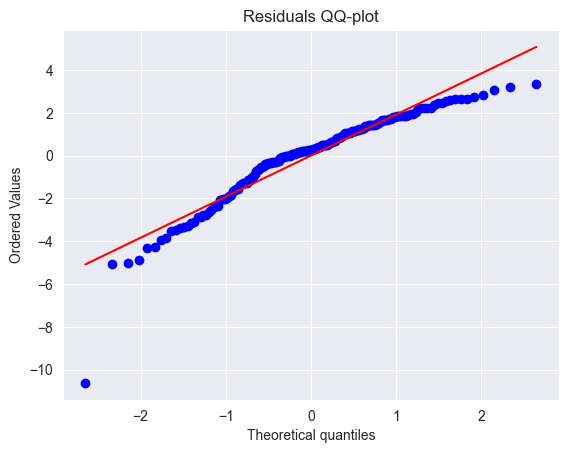

In [230]:
stats.probplot(resid_multi, dist="norm", plot=plt)
plt.title("Residuals QQ-plot")
plt.show()

The residuals are normally distributed. The Q-Q plot shows a distinct downward curvature (an arching pattern), which confirms that the distribution is left-skewed.

In [231]:
shapiro_stat_multi, shapiro_p_multi = stats.shapiro(resid_multi)
print(f"Shapiro–Wilk normality test: stat={shapiro_stat_multi:.3f}, p-value={shapiro_p_multi:.10f}")

print("Reject H₀ – the residuals are not normally distributed (for alpha 0.05).")

Shapiro–Wilk normality test: stat=0.914, p-value=0.0000000173
Reject H₀ – the residuals are not normally distributed (for alpha 0.05).


 This is further validated by the Shapiro-Wilk test (p<0.05), allowing us to formally reject the null hypothesis of normality.

## 5. Independence of Residuals (No Autocorrelation)

**Mathematical Definition**

This assumption states that the error terms for different observations are uncorrelated with each other. Formally, for any two different observations $i$ and $j$:

$$Cov(\epsilon_i, \epsilon_j) = 0 \quad \text{for} \quad i \neq j$$

In the context of **Time Series** data (where observations are ordered by time), this is often expressed as:

$$\rho = Corr(\epsilon_t, \epsilon_{t-1}) = 0$$

where $\rho$ (rho) is the correlation coefficient between an error and its immediate predecessor.

**General Definition**

Independence means that the error the model makes for one data point tells us nothing about the error it will make for the next one.

* **Positive Autocorrelation:** If the model overestimates sales today, it is likely to overestimate them tomorrow (errors cluster together).

* **Negative Autocorrelation:** An overestimate is typically followed by an underestimate (errors zigzag).

**Why It Matters**

If residuals are correlated (autocorrelation), OLS estimates are still unbiased, but they are no longer efficient. More importantly:

* Standard errors are underestimated, making $t$-statistics artificially high.

* You might conclude that YouTube or Facebook ads are statistically significant when they actually aren't (Type I error).

**Verification Methods**

1. **Durbin-Watson (DW) Test:**

   The most common statistic for detecting first-order autocorrelation. The DW value ranges from 0 to 4:

    * **DW ≈ 2:** No autocorrelation (The goal).
    * **DW < 2:** Evidence of positive autocorrelation.
    * **DW > 2:** Evidence of negative autocorrelation.

2. **Residuals vs. Index Plot:**

    We plot the residuals against the order of observations (e.g., time or row number).

   * **Ideal Result:** A random "white noise" pattern, all or most of coefficients are across the confidence interval, autocorrelation for them is nearly 0.

   * **Warning Sign:** Successive points following a trend, wave, or "snake" pattern.

In [232]:
n = len(resid_multi)
lags = int(min(10 * math.log10(n), n - 1))
lags

22

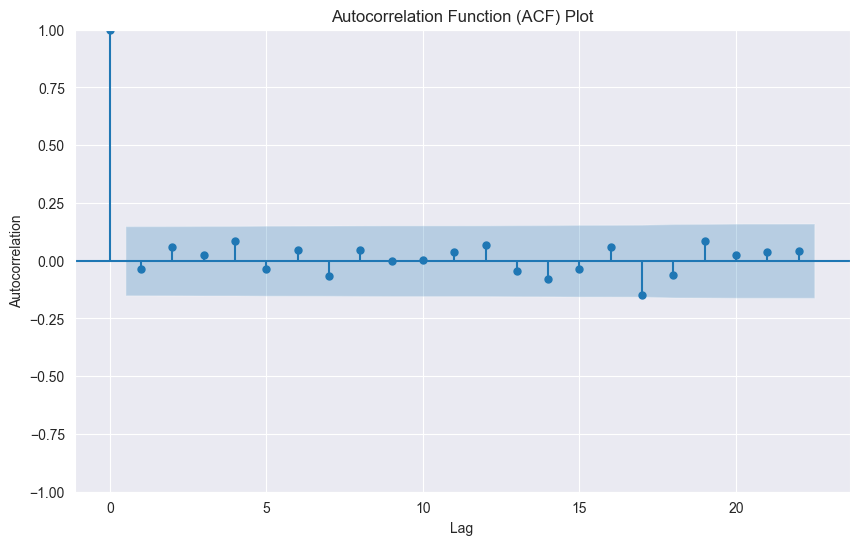

In [233]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(resid_multi, lags=lags, ax=ax)

plt.title('Autocorrelation Function (ACF) Plot')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.show()

All autocorrelation coefficients are nearly zero and remain within the 95% confidence intervals (significance boundaries). Since no significant spikes are observed, we can conclude that there is no serial correlation in the residuals. The error terms behave as white noise, confirming that the model has successfully captured all systematic patterns in the data.

**Durbin-Watson test**
1. **Analytical Calculation (The Formula)**

The test starts by calculating the DW statistic ($d$) based on the model's residuals ($e_t$). It measures the squared differences between successive error terms relative to the total error variance:

$$
d = \frac{\sum_{t=2}^{T}(e_t - e_{t-1})^2}{\sum_{t=1}^{T} e_t^2}
$$

This calculation is performed automatically by statistical libraries (like `statsmodels`) and results in a single numerical value between **0 and 4**.

2. **Relationship with Autocorrelation ($\rho$)**

To understand the meaning of the result, we use a simplified linear approximation. This explains why a value of **2.0** represents the "gold standard" of no correlation:

$$
d \approx 2(1 - \hat{\rho})
$$

- If the autocorrelation ($\hat{\rho}$) is 0, then $d \approx 2$
- If there is strong **positive** autocorrelation ($\hat{\rho} \to 1$), then $d \to 0$
- If there is strong **negative** autocorrelation ($\hat{\rho} \to -1$), then $d \to 4$

3. **Formal Decision (Critical Values $d_L$ and $d_U$)**

The final step is to compare the calculated $d$ against the **Durbin-Watson Critical Values Table**. Because the distribution of $d$ depends on the sample size ($n$) and the number of predictors ($k$), we identify two boundaries:

- **$d_L$ (Lower Bound):** The threshold for significant positive autocorrelation
- **$d_U$ (Upper Bound):** The threshold for confirmed independence

**Decision Rules for $\alpha = 0.05$:**

1. **Reject $H_0$**: If $d < d_L$, there is evidence of positive autocorrelation
2. **Fail to Reject $H_0$**: If $d > d_U$, there is no evidence of autocorrelation (residuals are independent)
3. **Inconclusive**: If $d_L < d < d_U$, the test cannot determine if correlation exists



 We have to check left and right boundary for alpha 0.05
 * k = 3 (independent variable - Facebook, Youtube, Newspaper )
 * n = 172 (sample size)
 1. dL
 * dL for 150 - 1.69
 * dL for 200 - 1.74
 * dL mean = 1.715
 2. dU
 * dU for 150 - 1.77
 * dU for 200 - 1.80
 * dU mean = 1.785
 <p> Based on https://www.statology.org/durbin-watson-table/ </p>

In [234]:
dL_multi = 1.715
dU_multi = 1.785
dw_statistic_multi = float(summary_multi.tables[2].data[0][3])

if dw_statistic_multi < dL_multi:
    print(f'DW Stat: {dw_statistic_multi:.2f} - Positive Autocorrelation (p < 0.05)')
    print('Assumption NOT satisfied')
elif dw_statistic_multi > (4 - dL_multi):
    print(f'DW Stat: {dw_statistic_multi:.2f} - Negative Autocorrelation (p < 0.05)')
    print('Assumption NOT satisfied')
elif dU_multi < dw_statistic_multi < (4 - dU_multi):
    print(f'DW Stat: {dw_statistic_multi:.2f} - No Autocorrelation (p > 0.05)')
    print('Assumption satisfied')
else:
    print(f'DW Stat: {dw_statistic_multi:.2f} - Inconclusive zone')

DW Stat: 2.06 - No Autocorrelation (p > 0.05)
Assumption satisfied


We have no grounds to reject the null hypothesis (H0​).

## 6. No Multicollinearity

**General Definition**

Multicollinearity occurs when two or more independent variables (predictors) in a regression model are **highly correlated** with each other.

In your case, if spending on YouTube always increases exactly when spending on Facebook increases, the model cannot distinguish which one is actually driving the "Sales." They are "talking over each other," making it impossible to isolate the individual effect of each marketing channel.

**Why It Is a Problem**

While multicollinearity doesn't usually reduce the overall predictive power of the model, it creates several "technical nightmares":

- **Unstable Coefficients**: Small changes in the data can lead to wild swings in your $\beta$ parameters
- **Inflated Standard Errors**: It becomes difficult for the model to prove that a variable is "significant"
- **Lower T-statistics**: You might get a high $R^2$ (the model looks good overall), but none of your individual variables (YouTube, Facebook) show a significant p-value

**Verification Method: Variance Inflation Factor (VIF)**

The most common way to measure multicollinearity is the VIF. It quantifies how much the variance of an estimated regression coefficient is "inflated" due to correlation with other predictors.

**The Logic of VIF**

For each variable $X_j$, we run a separate regression where $X_j$ is the dependent variable and all other $X$'s are the predictors. We then calculate:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

- $R_j^2$: The coefficient of determination from that "sub-regression." If $R_j^2$ is high (close to 1), it means $X_j$ can be almost perfectly predicted by the other variables.

**Decision Rules for VIF:**

- **VIF = 1**: No correlation at all
- **1 < VIF < 5**: Moderate multicollinearity (usually acceptable)
- **VIF > 5 or 10**: High multicollinearity — "danger zone", consider removing or combining variables


In [235]:
y_for_vif, X_for_vif =dmatrices('sales ~ facebook+youtube+newspaper', data=df, return_type='dataframe')
X_for_vif # DataFrame only for independent variables X

,Intercept,facebook,youtube,newspaper
0,1.0,19.20,84.72,48.96
1,1.0,33.96,351.48,51.84
2,1.0,20.88,135.48,46.32
3,1.0,1.80,116.64,36.00
4,1.0,24.00,318.72,0.36
...,...,...,...,...
166,1.0,4.44,45.84,16.56
167,1.0,5.88,113.04,9.72
168,1.0,11.16,212.40,7.68
169,1.0,50.40,340.32,79.44


In [236]:
vif = pd.DataFrame() # Blank DataFrame
vif

""


In [237]:
vif['VIF'] = [variance_inflation_factor(X_for_vif.values, i) for i in range(1, X_for_vif.shape[1])]     # variance_inflation_factor(matrix.values, number of column)
vif['variable'] = X_for_vif.columns[1:]
vif

,VIF,variable
0,1.097761,facebook
1,1.015706,youtube
2,1.103072,newspaper


The VIF values for all predictors (YouTube, Facebook, and Newspaper) are between 1.01 and 1.10. Since these values are well below the threshold of 5, there is no multicollinearity in our model.

## 7. Exogeneity (Omitted in This Analysis)

**General Definition**

Exogeneity is a key assumption of the linear regression model stating that the error term is independent of the predictors:

$$
\mathbb{E}[\varepsilon \mid X] = 0
$$

This means that the model includes all relevant variables and there is no systematic relationship between the predictors and the error term.

In simpler terms: predictors should not "carry" hidden information about the error.

**Why It Is Important**

If exogeneity is violated, the model suffers from **endogeneity**, which leads to:

- **Biased coefficients** ($\beta$ are systematically wrong)
- **Inconsistent estimators** (results do not converge to true values even with large samples)
- **Misleading inference** (p-values and confidence intervals are unreliable)

This is one of the **most serious violations** in linear regression.

**Main Sources of Endogeneity**

- **Omitted Variable Bias**: A relevant variable is missing and is correlated with both $X$ and $y$
- **Simultaneity**: $X$ and $y$ affect each other (e.g. demand ↔ price)
- **Measurement Error**: Predictor is measured with noise

**How to Check (Indirectly)**

Exogeneity **cannot be directly tested**, but we use diagnostic approaches:

- **Theory / Domain Knowledge**: The most important check — does the model make causal sense?
- **Residual Analysis**: Look for patterns suggesting missing variables
- **Durbin–Wu–Hausman Test**: Formal statistical test for endogeneity
- **Instrumental Variables (IV) approach**: Compare OLS vs IV estimates

**When to React**

You should suspect a violation if:

- Adding/removing variables causes large changes in coefficients
- Signs of coefficients are counterintuitive
- Model performs well ($R^2$ high) but results make no economic sense
- Strong correlation between residuals and predictors

**Possible Solutions**

- Add missing relevant variables
- Use **Instrumental Variables (IV)**
- Use **panel data methods** (fixed effects)
- Redesign the model (causal structure)

**Summary (Regression Assumptions Context)**

Exogeneity is a **core assumption of OLS**. Without it:

- Even if all other assumptions (no autocorrelation, homoskedasticity, no multicollinearity) hold
- The model can still be fundamentally incorrect

This is why exogeneity is often considered **more critical than other assumptions**


## 8. Outliers and Influential Observations
Outliers are observations with extreme values compared to the rest of the data, which can distort model estimates and violate assumptions like normality or homoscedasticity. Influential points are observations that have a disproportionately large impact on the fitted model (e.g., coefficients), often identified using measures like Cook’s distance or leverage.

In [238]:
influence_multi = OLSInfluence(results_multi)

student_resid_multi = influence_multi.resid_studentized_internal
leverage_multi  = influence_multi.hat_matrix_diag
cooks_multi = influence_multi.cooks_distance[0]

diagnostics_multi = pd.DataFrame({
    "youtube": df["youtube"],
    "facebook": df["facebook"],
    "newspaper": df["newspaper"],
    "sales": df["sales"],
    "student_resid": student_resid_multi,
    "leverage": leverage_multi,
    "cooks_d": cooks_multi,
}, index=df.index)

diagnostics_multi.sort_values("cooks_d", ascending=False).head(10)

,youtube,facebook,newspaper,sales,student_resid,leverage,cooks_d
101,0.84,47.52,10.44,1.92,-5.397893,0.041608,0.316243
46,20.28,52.44,107.28,10.44,-2.239764,0.078289,0.106524
6,348.84,4.92,10.20,15.36,-2.483835,0.038063,0.061029
97,9.36,46.68,60.72,7.92,-2.564808,0.035190,0.059983
136,281.40,4.08,101.76,14.28,-1.639127,0.080415,0.058737
149,332.04,2.76,28.44,14.16,-2.533371,0.032850,0.054497
49,6.48,35.88,11.28,6.36,-2.145818,0.030341,0.036020
99,264.36,58.80,3.84,29.64,1.571460,0.048189,0.031257
129,14.04,44.28,54.24,8.76,-1.998395,0.030269,0.031164
102,318.24,3.48,51.60,15.24,-1.792129,0.035212,0.029305


### Studentized Residuals
Studentized residuals are standardized residuals that account for the varying variance of each observation, making them more reliable for detecting outliers than raw residuals. They are computed by dividing each residual by an estimate of its standard deviation, allowing for consistent comparison across observations.

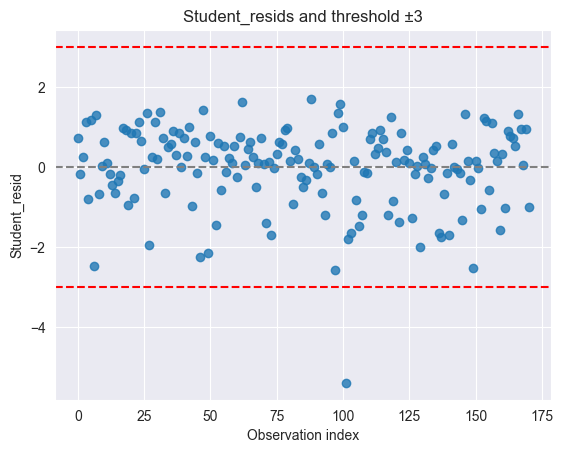

,youtube,facebook,newspaper,sales,student_resid,leverage,cooks_d
101,0.84,47.52,10.44,1.92,-5.397893,0.041608,0.316243


In [239]:
plt.scatter(range(len(student_resid_multi)), student_resid_multi, alpha=0.8)
plt.axhline(0, linestyle="--", color="grey")
plt.axhline(3, linestyle="--", color="red")
plt.axhline(-3, linestyle="--", color="red")
plt.xlabel("Observation index")
plt.ylabel("Student_resid")
plt.title("Student_resids and threshold ±3")
plt.show()

outliers_multi = diagnostics_multi.loc[np.abs(diagnostics_multi["student_resid"]) > 3].sort_values("student_resid")
outliers_multi

# outliers = diagnostics_multi[np.abs(diagnostics_multi['student_resid']) > 3]
# outliers_multi

We observe the exact same outlier at index 101. In this observation, the spend on Facebook is high, yet the resulting sales are extremely low. This contradicts the strong positive correlation seen in the rest of the dataset.

### Cook's Distance

Cook’s distance ($D_i$) measures how much all fitted values in a regression model would change if a given observation were removed, combining information about both residual size and leverage. Large values of $D_i$ indicate influential observations, with a common rule of thumb being $D_i > \frac{4}{n}$ as a signal to investigate further.

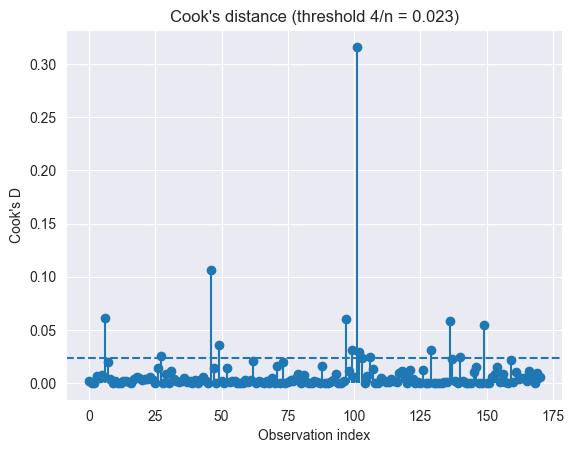

,youtube,facebook,newspaper,sales,student_resid,leverage,cooks_d
101,0.84,47.52,10.44,1.92,-5.397893,0.041608,0.316243
46,20.28,52.44,107.28,10.44,-2.239764,0.078289,0.106524
6,348.84,4.92,10.20,15.36,-2.483835,0.038063,0.061029
97,9.36,46.68,60.72,7.92,-2.564808,0.035190,0.059983
136,281.40,4.08,101.76,14.28,-1.639127,0.080415,0.058737
149,332.04,2.76,28.44,14.16,-2.533371,0.032850,0.054497
49,6.48,35.88,11.28,6.36,-2.145818,0.030341,0.036020
99,264.36,58.80,3.84,29.64,1.571460,0.048189,0.031257
129,14.04,44.28,54.24,8.76,-1.998395,0.030269,0.031164
102,318.24,3.48,51.60,15.24,-1.792129,0.035212,0.029305


In [240]:
n = len(resid_multi)
threshold = 4 / n     # Thumb Rule for Cook's Distance

plt.stem(cooks_multi, basefmt=" ")
plt.axhline(threshold, linestyle="--")
plt.title(f"Cook's distance (threshold 4/n = {threshold:.3f})")
plt.xlabel("Observation index")
plt.ylabel("Cook's D")
plt.show()

diagnostics_multi.loc[diagnostics_multi["cooks_d"] > threshold].sort_values("cooks_d", ascending=False)

The Cook's distance plot highlights one highly influential observation at index 101, with a value exceeding 0.30. An observation with such high Cook's Distance significantly distorts the regression coefficients. It means the entire model is being "pulled" towards this single, anomalous data point. Observation 101 was previously identified as a severe outlier (Studentized Residual < -5), and now as a highly influential point

***
# Evaluating Model Performance

### R2 Score

In [241]:
print("R^2 Score: ", results_multi.rsquared)

R^2 Score:  0.9004752358539351


The model demonstrates very high predictive power, explaining approximately 90% of the variance in Sales based on YouTube, Facebook, and Newspaper advertising budgets.

### RMSE

In [242]:
y_pred_multi = results_multi.predict(X_multi) 
rmse_multi = np.sqrt(np.mean((y - y_pred_multi)**2))
print("RMSE:", rmse_multi)

RMSE: 1.986270329030222


On average, the model's sales predictions deviate by approximately 1.99 units from the actual values.

### Coefficients

In [243]:
summary_multi.tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,3.5059,0.400,8.772,0.000,2.717,4.295
youtube,0.0452,0.002,29.830,0.000,0.042,0.048
facebook,0.1884,0.009,20.895,0.000,0.171,0.206
newspaper,0.0043,0.007,0.658,0.511,-0.009,0.017


 Based on the regression summary, the relationship between advertising spend and sales is defined by the following equation.
 Sales = 3.5059 + 0.0452 * YouTube + 0.1884 * Facebook + 0.0043 * Newspaper
 * Facebook is the most efficient channel: For every unit increase in the Facebook budget, sales increase by 0.188, assuming other variables remain constant.
 * Youtube has a steady positive impact: It contributes 0.045 per budget unit and is highly statistically significant.
 * Newspaper is ineffective: With a p-value of 0.511, the impact of newspaper ads is not statistically different from zero.

### Rethink the outliers
The extreme outlier at index 101 (high FB spend, very low sales) should be investigated as a potential "failed campaign" or data error to prevent such losses in the future.